In [1]:
from models import *

path = "../data/Fashion-MNIST"
X_train, y_train, X_test, y_test = load_MINST_dataset(path)
X_train, X_test = flatten_images(X_train, X_test)

In [2]:
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.pipeline import Pipeline
import numpy as np

def tune_poly_pipeline(X_train, y_train, X_test, y_test, hp_list, dim_reduction):
    results = {}
    
    for hp in hp_list:
        pipeline = Pipeline([
            ('scaler', StandardScaler()),
            ('reduce_dim', dim_reduction),
            ('svc', SVC(kernel='poly', C=hp[0], gamma=hp[1], degree = hp[2], random_state=42))
        ], verbose=True)
        print(f"Training Polynomial SVC with hp={hp}...")
        results[hp] = evaluate_pipeline(pipeline, X_train, y_train, X_test, y_test)
        
    return results

def plot_poly_bar_chart(result, title):
    tuples = list(result.keys())
    
    x_labels = [f"C={c}\nγ={g}\nd={d}" for c, g, d in tuples]

    train_acc = [result[k]['train_acc'] for k in tuples]
    test_acc = [result[k]['test_acc'] for k in tuples]

    x = np.arange(len(x_labels)) 
    width = 0.35

    fig, ax = plt.subplots(figsize=(10, 6))
    
    ax.bar(x - width/2, train_acc, width, label='Train Accuracy', color='#4C72B0')
    ax.bar(x + width/2, test_acc, width, label='Test Accuracy', color='#55A868')

    ax.set_ylabel('Accuracy')
    ax.set_title(f'Hyperparameter Tuning: {title}')
    ax.set_xticks(x)
    ax.set_xticklabels(x_labels)
    ax.legend(loc='lower right')
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    
    min_acc = min(min(train_acc), min(test_acc))
    ax.set_ylim([max(0, min_acc - 0.02), 1.0])

    plt.tight_layout()
    plt.show()

    table = pd.DataFrame(result).T
    table.index = pd.MultiIndex.from_tuples(table.index, names=['C', 'Gamma', 'Degree'])
    table = table[['train_time', 'train_acc', 'test_acc']].copy()
    table.columns = ['Training Time', 'Training Accuracy', 'Test Accuracy']

    return result, table

Training Polynomial SVC with hp=(10, 0.001, 2)...
[Pipeline] ............ (step 1 of 3) Processing scaler, total=   2.4s
[Pipeline] ........ (step 2 of 3) Processing reduce_dim, total=   2.3s
[Pipeline] ............... (step 3 of 3) Processing svc, total= 1.3min
Training Polynomial SVC with hp=(10, 0.001, 3)...
[Pipeline] ............ (step 1 of 3) Processing scaler, total=   1.4s
[Pipeline] ........ (step 2 of 3) Processing reduce_dim, total=   0.8s
[Pipeline] ............... (step 3 of 3) Processing svc, total= 1.4min
Training Polynomial SVC with hp=(30, 0.001, 2)...
[Pipeline] ............ (step 1 of 3) Processing scaler, total=   1.3s
[Pipeline] ........ (step 2 of 3) Processing reduce_dim, total=   1.1s
[Pipeline] ............... (step 3 of 3) Processing svc, total= 1.2min
Training Polynomial SVC with hp=(30, 0.001, 3)...
[Pipeline] ............ (step 1 of 3) Processing scaler, total=   1.2s
[Pipeline] ........ (step 2 of 3) Processing reduce_dim, total=   1.1s
[Pipeline] ........

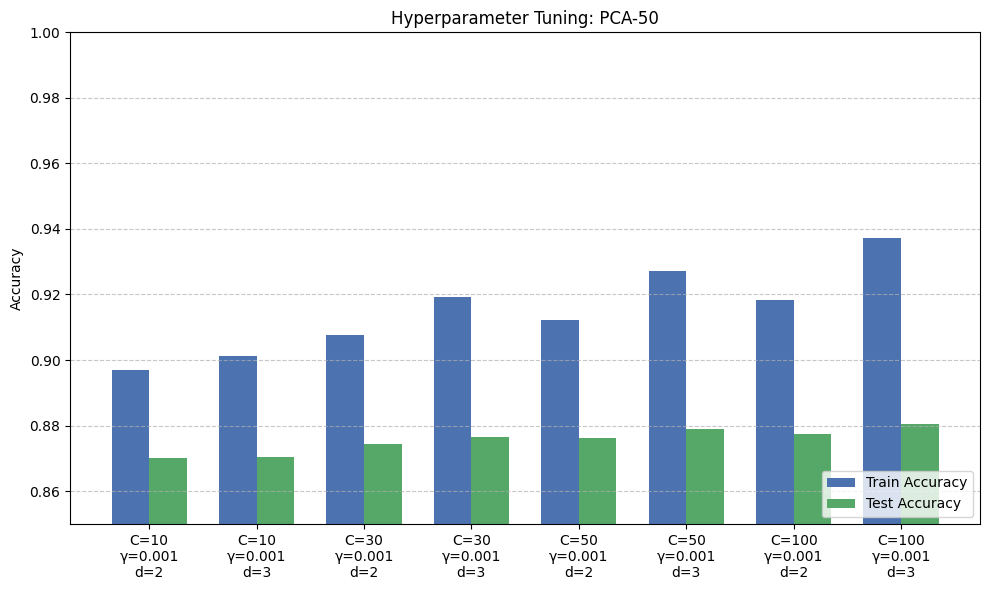

({(10, 0.001, 2): {'train_time': 83.28395189996809,
   'train_acc': 0.8969833333333334,
   'test_acc': 0.87},
  (10, 0.001, 3): {'train_time': 84.87008189997869,
   'train_acc': 0.9012666666666667,
   'test_acc': 0.8703},
  (30, 0.001, 2): {'train_time': 75.30511670000851,
   'train_acc': 0.9076,
   'test_acc': 0.8745},
  (30, 0.001, 3): {'train_time': 77.96769249998033,
   'train_acc': 0.9193833333333333,
   'test_acc': 0.8764},
  (50, 0.001, 2): {'train_time': 79.03447020001477,
   'train_acc': 0.9122166666666667,
   'test_acc': 0.8763},
  (50, 0.001, 3): {'train_time': 74.23563050001394,
   'train_acc': 0.92705,
   'test_acc': 0.879},
  (100, 0.001, 2): {'train_time': 80.71756020002067,
   'train_acc': 0.9183833333333333,
   'test_acc': 0.8773},
  (100, 0.001, 3): {'train_time': 76.40095919999294,
   'train_acc': 0.93715,
   'test_acc': 0.8806}},
                   Training Time  Training Accuracy  Test Accuracy
 C   Gamma Degree                                                 
 10 

In [3]:
fine_options_50 = [
    (10, 0.001, 2),
    (10, 0.001, 3),
    (30, 0.001, 2),
    (30, 0.001, 3),
    (50, 0.001, 2),
    (50, 0.001, 3),
    (100, 0.001, 2),
    (100, 0.001, 3),
]
result_50 = tune_poly_pipeline(X_train, y_train, X_test, y_test, fine_options_50, PCA(n_components=50))
plot_poly_bar_chart(result_50, "PCA-50")

Training Polynomial SVC with hp=(10, 0.0005, 2)...
[Pipeline] ............ (step 1 of 3) Processing scaler, total=   2.7s
[Pipeline] ........ (step 2 of 3) Processing reduce_dim, total=   1.7s
[Pipeline] ............... (step 3 of 3) Processing svc, total= 2.0min
Training Polynomial SVC with hp=(10, 0.0005, 3)...
[Pipeline] ............ (step 1 of 3) Processing scaler, total=   1.5s
[Pipeline] ........ (step 2 of 3) Processing reduce_dim, total=   1.3s
[Pipeline] ............... (step 3 of 3) Processing svc, total= 2.7min
Training Polynomial SVC with hp=(30, 0.0005, 2)...
[Pipeline] ............ (step 1 of 3) Processing scaler, total=   1.5s
[Pipeline] ........ (step 2 of 3) Processing reduce_dim, total=   1.1s
[Pipeline] ............... (step 3 of 3) Processing svc, total= 1.5min
Training Polynomial SVC with hp=(30, 0.0003, 2)...
[Pipeline] ............ (step 1 of 3) Processing scaler, total=   1.3s
[Pipeline] ........ (step 2 of 3) Processing reduce_dim, total=   1.3s
[Pipeline] ....

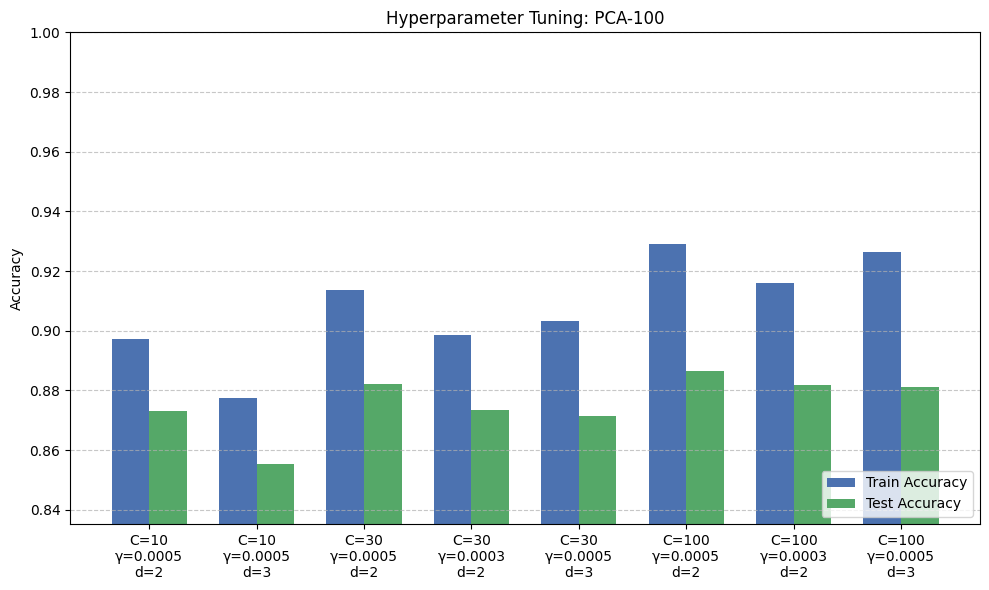

({(10, 0.0005, 2): {'train_time': 125.30728789995192,
   'train_acc': 0.8970833333333333,
   'test_acc': 0.873},
  (10, 0.0005, 3): {'train_time': 167.16566410002997,
   'train_acc': 0.8775166666666666,
   'test_acc': 0.8553},
  (30, 0.0005, 2): {'train_time': 94.32811649999348,
   'train_acc': 0.9135833333333333,
   'test_acc': 0.8821},
  (30, 0.0003, 2): {'train_time': 106.32285390002653,
   'train_acc': 0.8986833333333333,
   'test_acc': 0.8735},
  (30, 0.0005, 3): {'train_time': 111.22211999999126,
   'train_acc': 0.9033333333333333,
   'test_acc': 0.8713},
  (100, 0.0005, 2): {'train_time': 83.7321188999922,
   'train_acc': 0.92895,
   'test_acc': 0.8865},
  (100, 0.0003, 2): {'train_time': 87.38863139995374,
   'train_acc': 0.9159666666666667,
   'test_acc': 0.8817},
  (100, 0.0005, 3): {'train_time': 94.08241410000483,
   'train_acc': 0.9262666666666667,
   'test_acc': 0.8812}},
                    Training Time  Training Accuracy  Test Accuracy
 C   Gamma  Degree               

In [4]:
fine_options_100 = [
    (10, 0.0005, 2),
    (10, 0.0005, 3),
    (30, 0.0005, 2),
    (30, 0.0003, 2),
    (30, 0.0005, 3),
    (100, 0.0005, 2),
    (100, 0.0003, 2),
    (100, 0.0005, 3),
]
result_100 = tune_poly_pipeline(X_train, y_train, X_test, y_test, fine_options_100, PCA(n_components=100))
plot_poly_bar_chart(result_100, "PCA-100")

Training Polynomial SVC with hp=(50, 0.0001, 2)...
[Pipeline] ............ (step 1 of 3) Processing scaler, total=   2.6s
[Pipeline] ........ (step 2 of 3) Processing reduce_dim, total=   1.6s
[Pipeline] ............... (step 3 of 3) Processing svc, total= 3.7min
Training Polynomial SVC with hp=(50, 5e-05, 2)...
[Pipeline] ............ (step 1 of 3) Processing scaler, total=   1.3s
[Pipeline] ........ (step 2 of 3) Processing reduce_dim, total=   1.0s
[Pipeline] ............... (step 3 of 3) Processing svc, total= 5.3min
Training Polynomial SVC with hp=(100, 0.0001, 2)...
[Pipeline] ............ (step 1 of 3) Processing scaler, total=   1.7s
[Pipeline] ........ (step 2 of 3) Processing reduce_dim, total=   1.3s
[Pipeline] ............... (step 3 of 3) Processing svc, total= 3.7min
Training Polynomial SVC with hp=(100, 5e-05, 2)...
[Pipeline] ............ (step 1 of 3) Processing scaler, total=   1.1s
[Pipeline] ........ (step 2 of 3) Processing reduce_dim, total=   1.5s
[Pipeline] ....

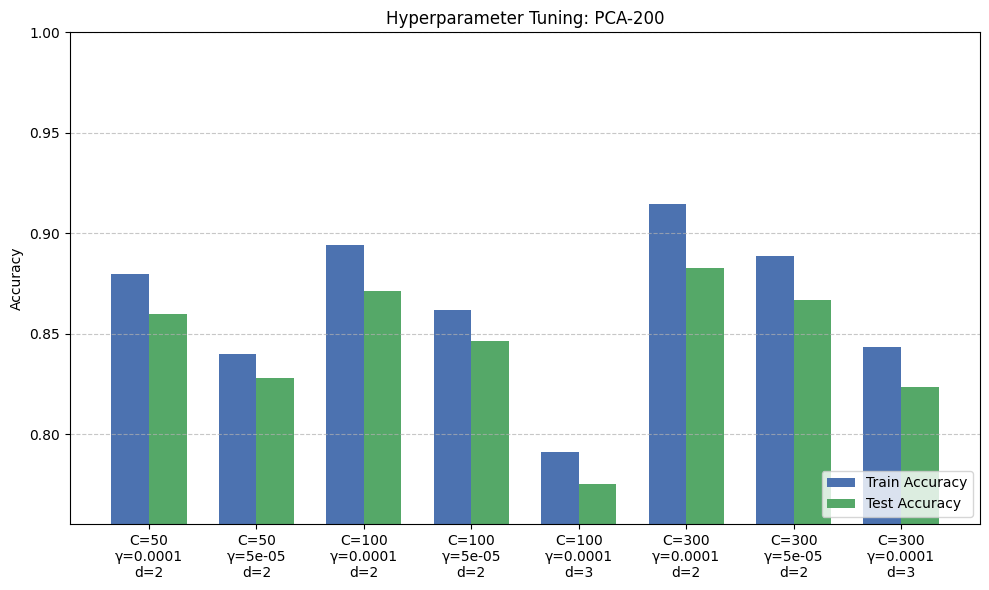

({(50, 0.0001, 2): {'train_time': 224.46062889997847,
   'train_acc': 0.8799166666666667,
   'test_acc': 0.8598},
  (50, 5e-05, 2): {'train_time': 322.7355726999813,
   'train_acc': 0.8397,
   'test_acc': 0.8278},
  (100, 0.0001, 2): {'train_time': 222.11472460004734,
   'train_acc': 0.89405,
   'test_acc': 0.8711},
  (100, 5e-05, 2): {'train_time': 235.2326686999877,
   'train_acc': 0.8619833333333333,
   'test_acc': 0.8461},
  (100, 0.0001, 3): {'train_time': 406.744574500015,
   'train_acc': 0.79095,
   'test_acc': 0.7753},
  (300, 0.0001, 2): {'train_time': 125.69984300003853,
   'train_acc': 0.9146166666666666,
   'test_acc': 0.8828},
  (300, 5e-05, 2): {'train_time': 166.1762185000116,
   'train_acc': 0.8886833333333334,
   'test_acc': 0.8669},
  (300, 0.0001, 3): {'train_time': 272.04156320000766,
   'train_acc': 0.8434166666666667,
   'test_acc': 0.8236}},
                     Training Time  Training Accuracy  Test Accuracy
 C   Gamma   Degree                                   

In [5]:
fine_options_200 = [
    (50, 0.0001, 2),
    (50, 0.00005, 2),
    (100, 0.0001, 2),
    (100, 0.00005, 2),
    (100, 0.0001, 3),
    (300, 0.0001, 2),
    (300, 0.00005, 2),
    (300, 0.0001, 3),
]
result_200 = tune_poly_pipeline(X_train, y_train, X_test, y_test, fine_options_200, PCA(n_components=200))
plot_poly_bar_chart(result_200, "PCA-200")

Training Polynomial SVC with hp=(10, 0.01, 2)...
[Pipeline] ............ (step 1 of 3) Processing scaler, total=   1.5s
[Pipeline] ........ (step 2 of 3) Processing reduce_dim, total=  14.7s
[Pipeline] ............... (step 3 of 3) Processing svc, total=  25.6s
Training Polynomial SVC with hp=(10, 0.01, 3)...
[Pipeline] ............ (step 1 of 3) Processing scaler, total=   1.2s
[Pipeline] ........ (step 2 of 3) Processing reduce_dim, total=  12.5s
[Pipeline] ............... (step 3 of 3) Processing svc, total=  25.8s
Training Polynomial SVC with hp=(10, 0.1, 2)...
[Pipeline] ............ (step 1 of 3) Processing scaler, total=   0.9s
[Pipeline] ........ (step 2 of 3) Processing reduce_dim, total=  12.0s
[Pipeline] ............... (step 3 of 3) Processing svc, total=  49.5s
Training Polynomial SVC with hp=(10, 0.1, 3)...
[Pipeline] ............ (step 1 of 3) Processing scaler, total=   0.9s
[Pipeline] ........ (step 2 of 3) Processing reduce_dim, total=  11.9s
[Pipeline] ..............

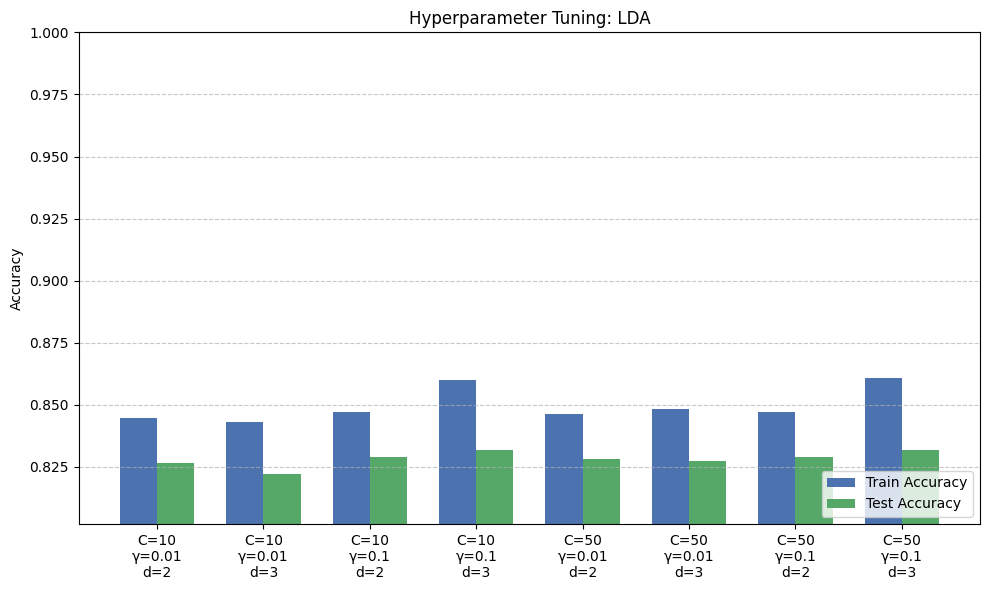

({(10, 0.01, 2): {'train_time': 41.813623299996834,
   'train_acc': 0.8445833333333334,
   'test_acc': 0.8268},
  (10, 0.01, 3): {'train_time': 39.55345120001584,
   'train_acc': 0.8432,
   'test_acc': 0.8221},
  (10, 0.1, 2): {'train_time': 62.35918849997688,
   'train_acc': 0.8472166666666666,
   'test_acc': 0.829},
  (10, 0.1, 3): {'train_time': 119.76894300000276,
   'train_acc': 0.86005,
   'test_acc': 0.8318},
  (50, 0.01, 2): {'train_time': 34.762873900006525,
   'train_acc': 0.8463833333333334,
   'test_acc': 0.8283},
  (50, 0.01, 3): {'train_time': 42.258464300015476,
   'train_acc': 0.8482833333333333,
   'test_acc': 0.8274},
  (50, 0.1, 2): {'train_time': 160.1578237999929,
   'train_acc': 0.8471666666666666,
   'test_acc': 0.8289},
  (50, 0.1, 3): {'train_time': 474.7241831999854,
   'train_acc': 0.8607333333333334,
   'test_acc': 0.8317}},
                  Training Time  Training Accuracy  Test Accuracy
 C  Gamma Degree                                                 
 10

In [6]:
fine_options_lda = [
    (10, 0.01, 2),
    (10, 0.01, 3),
    (10, 0.1, 2),
    (10, 0.1, 3),
    (50, 0.01, 2),
    (50, 0.01, 3),
    (50, 0.1, 2),
    (50, 0.1, 3),
]
result_lda = tune_poly_pipeline(X_train, y_train, X_test, y_test, fine_options_lda, LinearDiscriminantAnalysis(n_components=9))
plot_poly_bar_chart(result_lda, "LDA")